In [1]:
# Install (run once)
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [3]:
tesla = yf.download(
    "TSLA",
    start="2020-01-01",
    end=None   # Automatically fetch till today
)

tesla.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [4]:
tesla.reset_index(inplace=True)
tesla.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
1,2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2,2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
3,2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
4,2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [5]:
tesla.info()
tesla.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1559 entries, 0 to 1558
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1559 non-null   datetime64[ns]
 1   (Close, TSLA)   1559 non-null   float64       
 2   (High, TSLA)    1559 non-null   float64       
 3   (Low, TSLA)     1559 non-null   float64       
 4   (Open, TSLA)    1559 non-null   float64       
 5   (Volume, TSLA)  1559 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 73.2 KB


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
count,1559,1559.000000,1559.000000,1559.000000,1559.000000,1.559000e+03
mean,2023-02-05 19:45:04.041052160,243.179037,248.572965,237.563183,243.242887,1.189624e+08
min,2020-01-02 00:00:00,24.081333,26.990667,23.367332,24.980000,2.940180e+07
25%,2021-07-20 12:00:00,184.809998,188.235001,180.630005,184.980003,7.286140e+07
50%,2023-02-06 00:00:00,238.009995,243.300003,233.133331,237.470001,9.798870e+07
75%,2024-08-24 12:00:00,302.528320,309.429993,295.233322,301.686676,1.355464e+08
max,2026-03-17 00:00:00,489.880005,498.829987,485.329987,489.880005,9.140820e+08
std,NaN,101.086617,103.067708,99.156191,101.268059,7.647093e+07


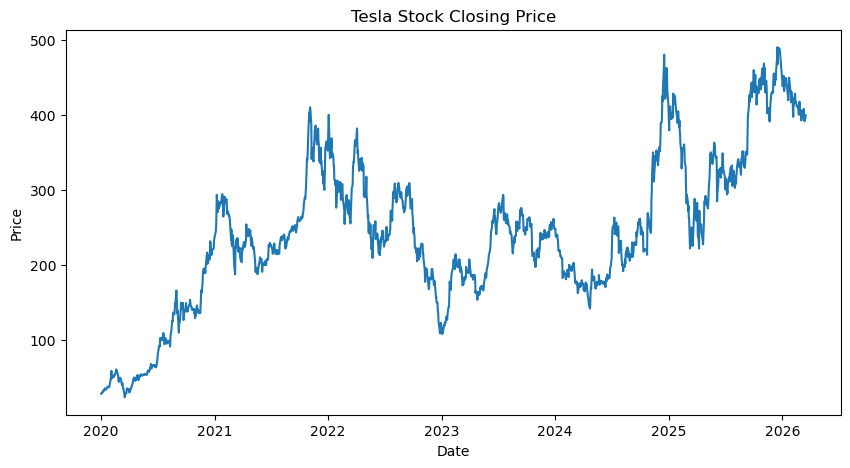

In [6]:
plt.figure(figsize=(10,5))
plt.plot(tesla['Date'], tesla['Close'])
plt.title("Tesla Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [7]:
# Moving averages
tesla['MA10'] = tesla['Close'].rolling(window=10).mean()
tesla['MA50'] = tesla['Close'].rolling(window=50).mean()

# Drop null values
tesla.dropna(inplace=True)

tesla.head()

Price,Date,Close,High,Low,Open,Volume,MA10,MA50
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA,,
49,2020-03-13,36.441334,40.504665,33.466667,39.666668,339604500,44.409200,43.886280
50,2020-03-16,29.671333,32.991333,29.478001,31.299999,307342500,42.418867,43.906026
51,2020-03-17,28.680000,31.456667,26.400000,29.334000,359919000,40.316800,43.888946
52,2020-03-18,24.081333,26.990667,23.367332,25.933332,356793000,37.728267,43.768520
53,2020-03-19,28.509333,30.133333,23.897333,24.980000,452932500,35.748933,43.713293


In [8]:
X = tesla[['Open', 'High', 'Low', 'Volume', 'MA10', 'MA50']]
y = tesla['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [9]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 3.3724163483905425
MSE: 18.243806243357387


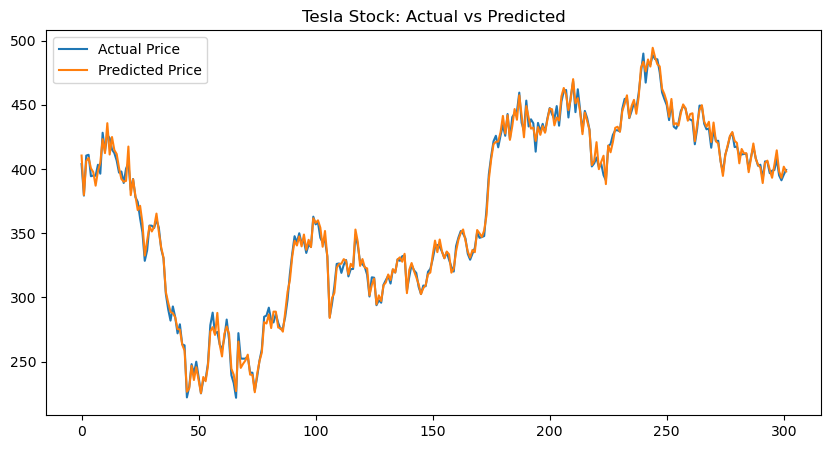

In [13]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.legend()
plt.title("Tesla Stock: Actual vs Predicted")
plt.show()

In [14]:
last_data = X.tail(1)

last_scaled = scaler.transform(last_data)

next_price = model.predict(last_scaled)

print("Predicted Next Day Tesla Price:", next_price[0])

Predicted Next Day Tesla Price: [398.00036511]


In [15]:
# Save dataset
tesla.to_csv("tesla_stock_data.csv")

# Save model
import pickle
with open("tesla_model.pkl", "wb") as f:
    pickle.dump(model, f)